# Middleware
Middleware provides us a way to more tightly control what happens inside the agent
* Tracking agent behaviour with logging, analytics, and debugging
* Transforming prompts, tool selection, and output formatting
* Adding retries, fallbacks, and early termination logic
* Applying rate limits, guardrails, and PII detection

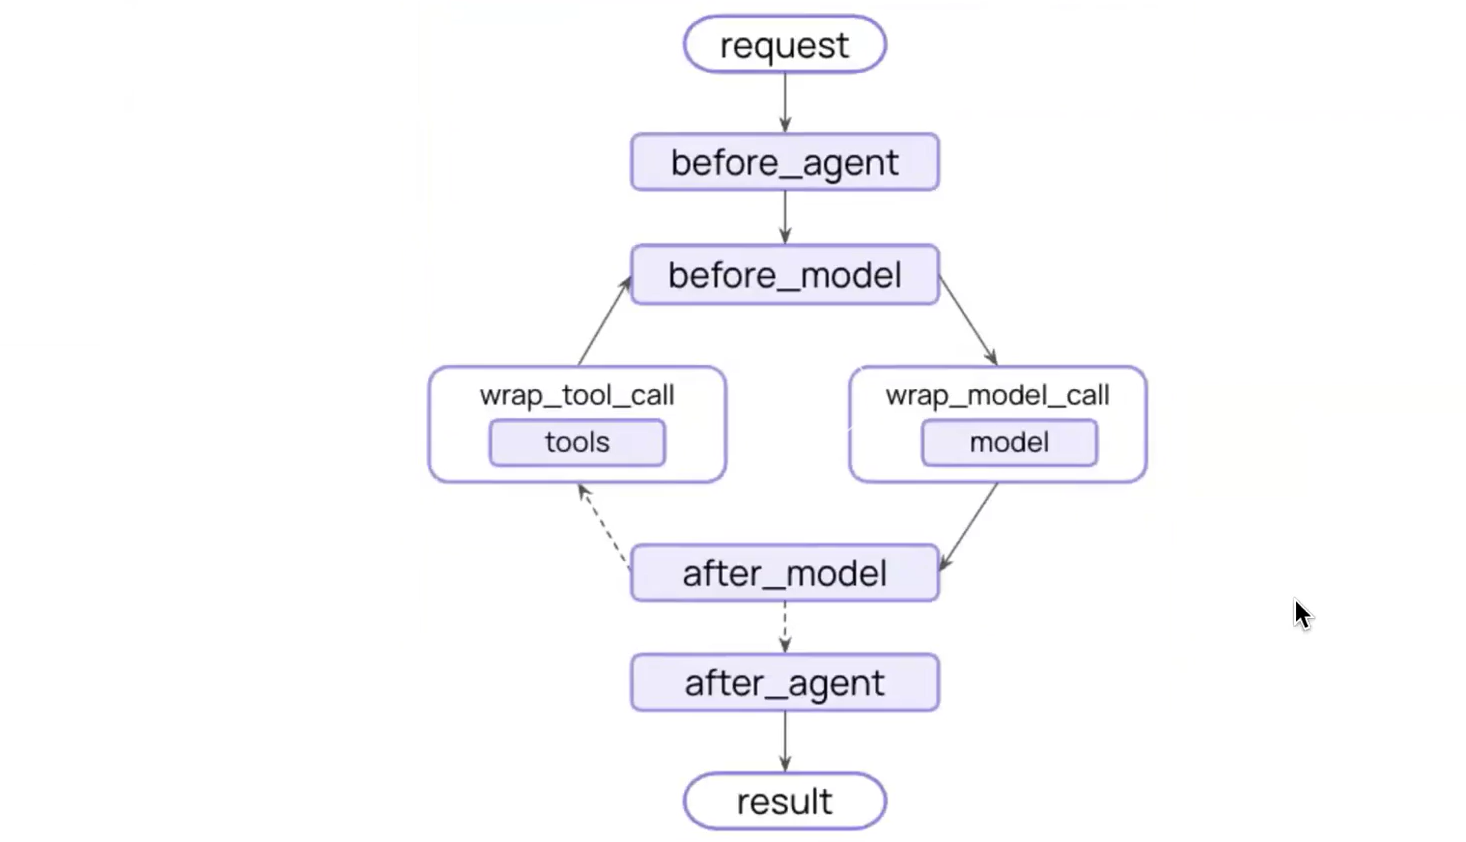

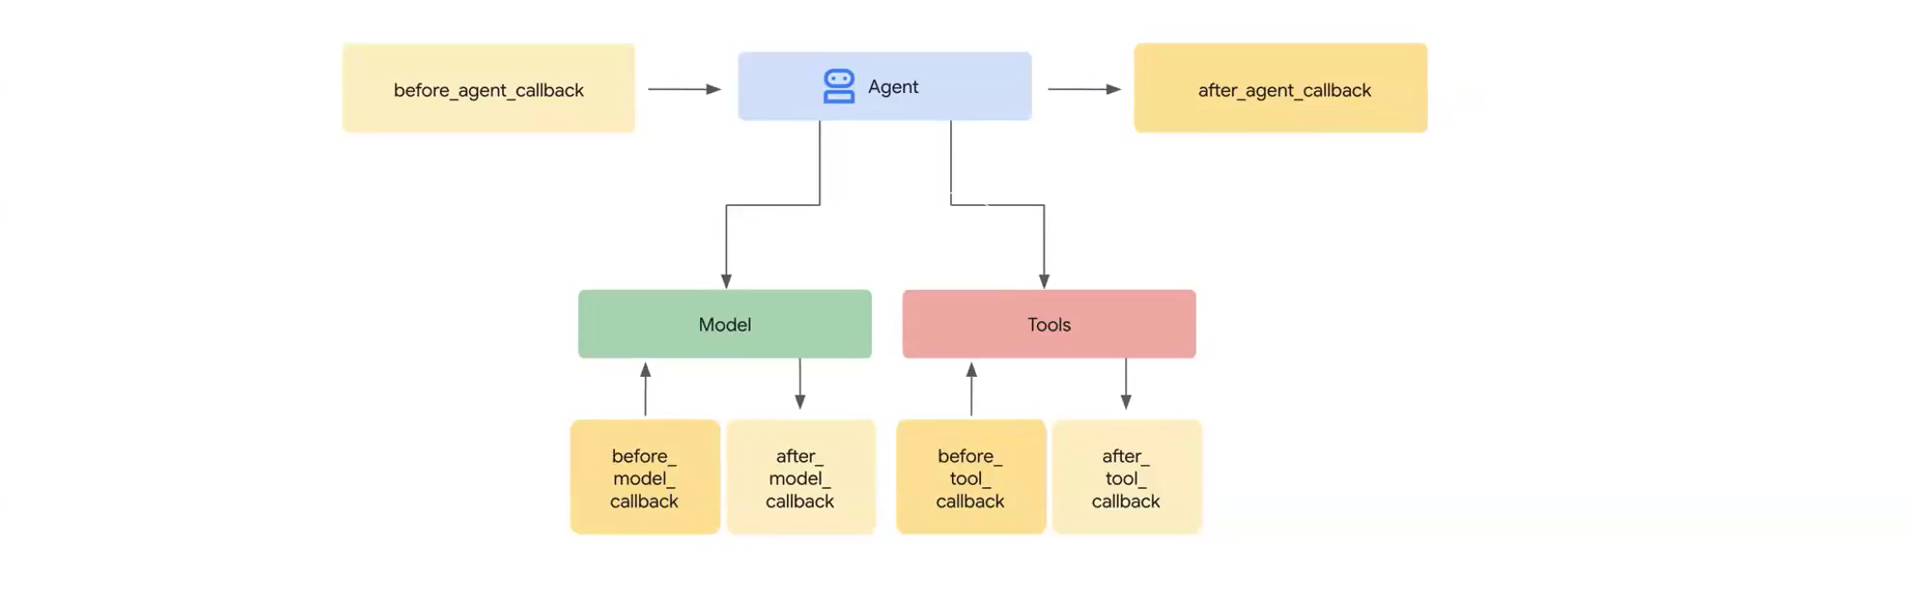
***callback is middleware for Google ADK***

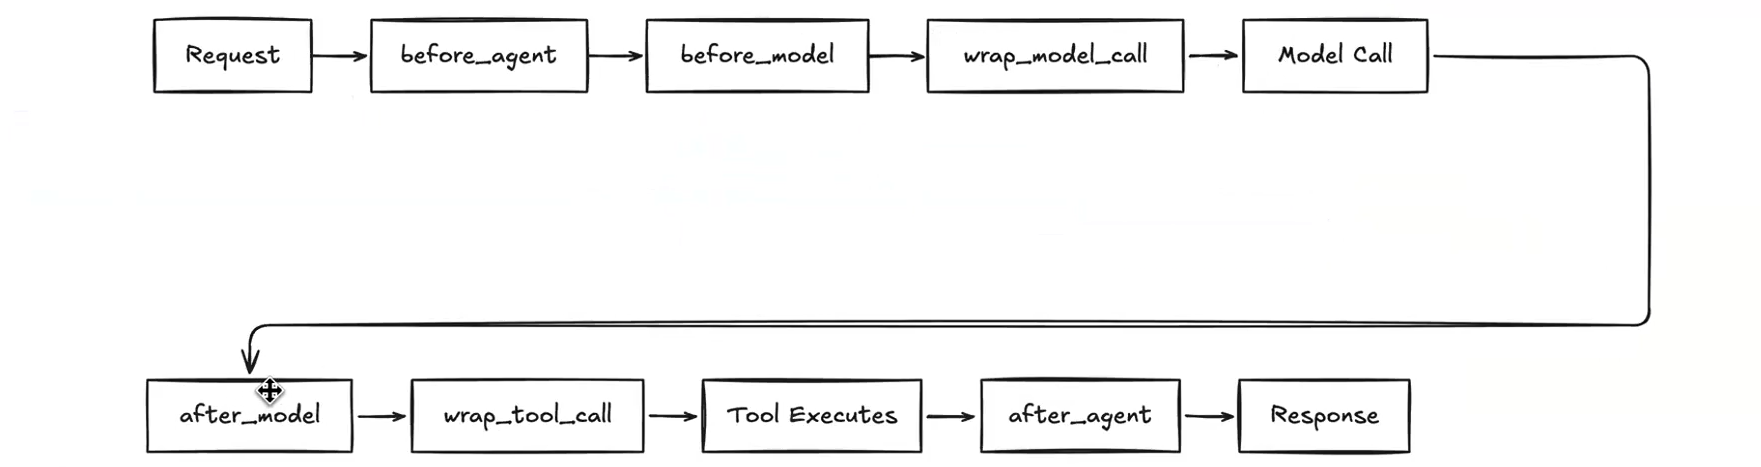


## Types of Middleware
1. Prebuilt (in the frameworks)
2. custom

In [3]:
# --- Core LangChain ---
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langchain_core.tools import tool
from langchain.tools import tool as tool_rt, ToolRuntime

# --- LangGraph (checkpointing, resuming) ---
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import Command

from langchain.agents.middleware import (
    SummarizationMiddleware,
    HumanInTheLoopMiddleware,
    ModelCallLimitMiddleware,
    ToolCallLimitMiddleware,
    ModelFallbackMiddleware,
    PIIMiddleware,
    TodoListMiddleware,
    LLMToolSelectorMiddleware,
    ToolRetryMiddleware,
    ModelRetryMiddleware,
    LLMToolEmulator,
    ContextEditingMiddleware,
    ClearToolUsesEdit,
)

from rich import print

In [4]:
# Dummy tools to test in-built middleware

@tool
def check_showtimes(movie_title: str) -> str:
    """Check available showtimes for a movie at the cinema."""
    fake_showtimes = {
        "interstellar": "7:00 PM and 10:15 PM",
        "dune part two": "9:30 PM only",
        "oppenheimer": "Sold out for tonight",
    }
    return fake_showtimes.get(movie_title.lower(), "No showtimes found for that title.")

@tool
def book_seats(movie_title: str, seat_count: int) -> str:
    """Book seats for a movie. Irreversible once confirmed."""
    return f"Booked {seat_count} seat(s) for {movie_title}."

@tool
def cancel_booking(booking_id: str) -> str:
    """Cancel an existing booking. Irreversible."""
    return f"Booking {booking_id} cancelled."

@tool
def check_order_status(booking_id: str) -> str:
    """Check the status of an existing booking."""
    return f"Booking {booking_id}: confirmed, 2 seats, Interstellar, 7:00 PM."

@tool
def get_refund_policy() -> str:
    """Get the cinema's refund policy -- exact wording, not to be paraphrased."""
    return "Refunds available up to 2 hours before showtime. No refunds after that."

@tool
def lookup_seat_map(movie_title: str, seat_number: str) -> str:
    """Look up a specific seat -- fails if the seat number format is wrong."""
    if not seat_number or not seat_number[0].isalpha():
        raise ValueError(f"Malformed seat number '{seat_number}' -- expected a letter+number like 'A12'.")
    return f"Seat {seat_number} for {movie_title}: available."


cinebot_tools = [check_showtimes, book_seats, cancel_booking, check_order_status, get_refund_policy, lookup_seat_map]

**Summarization Middleware**

In [6]:
# Pre-build Middleware: Summarization
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.agents.middleware import SummarizationMiddleware

@tool
def save_trip_demo(user_id: str, destination: str) -> str:
    """Save a trip to the database. Irreversible without manual cleanup."""
    return f"Trip to {destination} saved for {user_id}."  # standing in for a real DB write


agent = create_agent(
    model="openai:gpt-5-mini",
    tools=[save_trip_demo],
    middleware=[
        SummarizationMiddleware(
            model="gpt-5.4-mini",
            trigger=("tokens", 4000),
            keep=('messages', 10)
        )
    ]
)

**HITL (Human-in-the-Loop)**

In [7]:
guarded_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={"cancel_booking": {"allowed_decisions": ["approve", "edit", "reject", "respond"]}}
        ),
    ],
    checkpointer=InMemorySaver(),  # REQUIRED -- HITL needs to pause and later resume
)

config = {'configurable':{'thread_id':'hitl-demo-live-v1'}}

In [8]:
print(guarded_agent.invoke({"messages": [("user", "I am Linto . ")]},config=config))

{
    'messages': [
        HumanMessage(
            content='I am Linto . ',
            additional_kwargs={},
            response_metadata={},
            id='c78ddf2c-b1df-4fd7-9710-36d675eecb32'
        ),
        AIMessage(
            content='Hi Linto — nice to meet you. How can I help you today?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 153,
                    'prompt_tokens': 282,
                    'total_tokens': 435,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdG0CMCY6Q0w28pInMkSo20YGsK',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158d-dd43-7cb1-82a5-fc2cb98ee2ea-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 153,
                'total_tokens': 435,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        )
    ]
}

In [9]:
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)
print(result)

{
    'messages': [
        HumanMessage(
            content='I am Linto . ',
            additional_kwargs={},
            response_metadata={},
            id='c78ddf2c-b1df-4fd7-9710-36d675eecb32'
        ),
        AIMessage(
            content='Hi Linto — nice to meet you. How can I help you today?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 153,
                    'prompt_tokens': 282,
                    'total_tokens': 435,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdG0CMCY6Q0w28pInMkSo20YGsK',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158d-dd43-7cb1-82a5-fc2cb98ee2ea-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 153,
                'total_tokens': 435,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        ),
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='a4fc7cb7-ff04-4724-b11d-0a4cd51aa39b'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 26,
                    'prompt_tokens': 314,
                    'total_tokens': 340,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdI6iPmjDug8ic1RVEHy4N5AhYR',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1158d-e7d8-75d1-96f4-c0445896bef8-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_6Yz6z6wbYqDHx7OAh1p0i5Gu',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 314,
                'output_tokens': 26,
                'total_tokens': 340,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ],
    '__interrupt__': [
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 

In [10]:
state = guarded_agent.get_state(config)
print(state.tasks[0])

PregelTask(
    id='3adca6af-2dfd-c120-4785-312794990889',
    name='HumanInTheLoopMiddleware.after_model',
    path=('__pregel_pull', 'HumanInTheLoopMiddleware.after_model'),
    error=None,
    interrupts=(
        Interrupt(
            value={
                'action_requests': [
                    {
                        'name': 'cancel_booking',
                        'args': {'booking_id': 'BK1042'},
                        'description': "Tool execution requires approval\n\nTool: cancel_booking\nArgs: 
{'booking_id': 'BK1042'}"
                    }
                ],
                'review_configs': [
                    {
                        'action_name': 'cancel_booking',
                        'allowed_decisions': ['approve', 'edit', 'reject', 'respond']
                    }
                ]
            },
            id='f5581d153f480b7bcce7a4b63bf9e2ca'
        ),
    ),
    state=None,
    result=None
)

In [11]:
resumed_result = guarded_agent.invoke(Command(resume={"decisions":[{"type":"approve"}]}),config=config)
print(resumed_result)

{
    'messages': [
        HumanMessage(
            content='I am Linto . ',
            additional_kwargs={},
            response_metadata={},
            id='c78ddf2c-b1df-4fd7-9710-36d675eecb32'
        ),
        AIMessage(
            content='Hi Linto — nice to meet you. How can I help you today?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 153,
                    'prompt_tokens': 282,
                    'total_tokens': 435,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 128,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdG0CMCY6Q0w28pInMkSo20YGsK',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158d-dd43-7cb1-82a5-fc2cb98ee2ea-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 282,
                'output_tokens': 153,
                'total_tokens': 435,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 128}
            }
        ),
        HumanMessage(
            content='Please cancel booking BK1042',
            additional_kwargs={},
            response_metadata={},
            id='a4fc7cb7-ff04-4724-b11d-0a4cd51aa39b'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 26,
                    'prompt_tokens': 314,
                    'total_tokens': 340,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdI6iPmjDug8ic1RVEHy4N5AhYR',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1158d-e7d8-75d1-96f4-c0445896bef8-0',
            tool_calls=[
                {
                    'name': 'cancel_booking',
                    'args': {'booking_id': 'BK1042'},
                    'id': 'call_6Yz6z6wbYqDHx7OAh1p0i5Gu',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 314,
                'output_tokens': 26,
                'total_tokens': 340,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        ToolMessage(
            content='Booking BK1042 cancelled.',
            name='cancel_booking',
            id='ef392634-b3dc-4e12-aea1-7bfa403998f1',
            tool_call_id='call_6Yz6z6wbYqDHx7OAh1p0i5Gu'
        ),
        AIMessage(
            content='Done — your booking BK1042 has been cancelled. Would you like anything 

In [12]:
# creating interactive HITL
def run_interactive_hitl_demo(agent, config):
    """A genuinely interactive HITL loop -- ask out loud, type the answer, watch it apply live."""
    state = agent.get_state(config)
    if not state.next:
        print("Nothing is currently paused for approval.")
        return

    print("The agent wants to call a guarded tool. Choose a decision:")
    print("  1) approve  -- run it exactly as proposed")
    print("  2) edit     -- run it, but change the booking_id first")
    print("  3) reject   -- block it, with a reason sent back to the agent")
    print("  4) respond  -- answer a question instead of deciding on the action")

    choice = input("Type 1, 2, 3, or 4: ").strip()

    if choice == "1":
        decision = {"type": "approve"}
    elif choice == "2":
        new_id = input("New booking_id to use instead: ").strip()
        decision = {"type": "edit", "args": {"booking_id": new_id}}
    elif choice == "3":
        reason = input("Reason for rejecting: ").strip()
        decision = {"type": "reject", "message": reason}
    elif choice == "4":
        answer = input("Your response to the agent: ").strip()
        decision = {"type": "respond", "message": answer}
    else:
        print("Not a valid choice -- try again.")
        return

    resumed = agent.invoke(Command(resume={"decisions": [decision]}), config=config)
    print()
    print("Agent's final response:", resumed["messages"][-1].content)

In [13]:
config = {'configurable':{'thread_id':'hitl-demo-live-2'}}
result = guarded_agent.invoke({"messages": [("user", "Please cancel booking BK1042")]}, config=config)
run_interactive_hitl_demo(guarded_agent, config)

The agent wants to call a guarded tool. Choose a decision:

1) approve  -- run it exactly as proposed

2) edit     -- run it, but change the booking_id first

3) reject   -- block it, with a reason sent back to the agent

4) respond  -- answer a question instead of deciding on the action

Agent's final response: Done — booking BK1042 has been cancelled. This action is irreversible.

Would you like me to:
- Retrieve the cinema's refund policy?
- Check refund/status for this booking?
- Make a new booking instead?

Tell me which and I’ll proceed.

**Model Call Limit**

In [14]:
call_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),  # required for thread_limit to persist across calls
    middleware=[
        ModelCallLimitMiddleware( # low values taken just for example
            thread_limit=5,   # across the WHOLE conversation
            run_limit=2,       # per single .invoke() call
            exit_behavior="end",  # graceful stop, not an exception
        ),
    ],
)

# here for single .invoke() call it will call the model only twice, not more than that.
# AI message will be <= run_limit

In [15]:
result = call_limited_agent.invoke(
    {"messages": [("user", "Can you tell me cinema's refund policy? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

print(result)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='fbf7c412-e387-4853-9f9b-a80bd18f1612'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 286,
                    'total_tokens': 371,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHds0Fb9GLYJg2jOVoPWPdnZmgDT',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1158e-7562-74e2-8e8d-f46793637268-0',
            tool_calls=[
                {
                    'name': 'get_refund_policy',
                    'args': {},
                    'id': 'call_hze7E54UWZx17iDmPKOsigwk',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 85,
                'total_tokens': 371,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='9b6006da-5be0-48f5-ba6c-82de10a65bd0',
            tool_call_id='call_hze7E54UWZx17iDmPKOsigwk'
        ),
        AIMessage(
            content='Here\'s the cinema\'s refund policy exactly as provided:\n\n"Refunds available up to 2 hours 
before showtime. No refunds after that."',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 31,
                    'prompt_tokens': 331,
                    'total_tokens': 362,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdu40yXs2S2aRFusGOwaC5E1DGC',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158e-7c32-7032-99e3-2a68ea49fc91-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 331,
                'output_tokens': 31,
                'total_tokens': 362,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        )
    ]
}

In [16]:
result_invoke_2= call_limited_agent.invoke(
    {"messages": [("user", "cancel my booking B123? ")]},
    config={"configurable": {"thread_id": "call-limit-demo-4"}},
)

print(result_invoke_2)

{
    'messages': [
        HumanMessage(
            content="Can you tell me cinema's refund policy? ",
            additional_kwargs={},
            response_metadata={},
            id='fbf7c412-e387-4853-9f9b-a80bd18f1612'
        ),
        AIMessage(
            content='',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 85,
                    'prompt_tokens': 286,
                    'total_tokens': 371,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 64,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHds0Fb9GLYJg2jOVoPWPdnZmgDT',
                'service_tier': 'default',
                'finish_reason': 'tool_calls',
                'logprobs': None
            },
            id='lc_run--01a1158e-7562-74e2-8e8d-f46793637268-0',
            tool_calls=[
                {
                    'name': 'get_refund_policy',
                    'args': {},
                    'id': 'call_hze7E54UWZx17iDmPKOsigwk',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 286,
                'output_tokens': 85,
                'total_tokens': 371,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 64}
            }
        ),
        ToolMessage(
            content='Refunds available up to 2 hours before showtime. No refunds after that.',
            name='get_refund_policy',
            id='9b6006da-5be0-48f5-ba6c-82de10a65bd0',
            tool_call_id='call_hze7E54UWZx17iDmPKOsigwk'
        ),
        AIMessage(
            content='Here\'s the cinema\'s refund policy exactly as provided:\n\n"Refunds available up to 2 hours 
before showtime. No refunds after that."',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 31,
                    'prompt_tokens': 331,
                    'total_tokens': 362,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 0,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHdu40yXs2S2aRFusGOwaC5E1DGC',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158e-7c32-7032-99e3-2a68ea49fc91-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 331,
                'output_tokens': 31,
                'total_tokens': 362,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 0}
            }
        ),
        HumanMessage(
            content='cancel my booking B123? ',
            additional_kwargs={},
            response_metadata={},
            id='9ab1d34f-968f-4502-8bcf-a9aac8c

**Model Fallback**

In [17]:
resilient_agent = create_agent(
    model="openai:gpt-5.5-haiku",     # primary, most capable
    tools=cinebot_tools,
    middleware=[
        ModelFallbackMiddleware(
            "openai:gpt-5-mini",   # fallback -- cheaper, still OpenAI, needs no extra setup
            # "ollama:llama3.2",   # a further, fully-local last resort -- uncomment if you have
                                    # `pip install langchain-ollama` AND a local Ollama server running.
                                    # Left commented here so this cell runs with nothing beyond
                                    # what Setup already installed.
        ),
    ],
)

# Fallback chain: gpt-5.5 -> gpt-5-mini.
# If the primary model call fails for any reason, this silently tries the next one.

In [18]:
result = resilient_agent.invoke( {"messages": [("user", "Summarize my chat? ")]},)
print(result)

{
    'messages': [
        HumanMessage(
            content='Summarize my chat? ',
            additional_kwargs={},
            response_metadata={},
            id='677714a3-dd3e-4fe6-8cc3-331901acd040'
        ),
        AIMessage(
            content='Which chat do you want summarized — this current conversation, a different chat (paste or 
upload it), or a transcript/link?\n\nAlso tell me:\n- Desired length/format (one-line, short bullets, detailed 
chronology, action items, or tone analysis)\n- Any messages or sensitive info to exclude or redact\n- Whether you 
want a shareable version (polished for someone else)\n\nIf you want a quick summary of this session right now: "You
asked me to summarize your chat; I asked which chat and what summary style you prefer." Should I proceed?',
            additional_kwargs={'refusal': None},
            response_metadata={
                'token_usage': {
                    'completion_tokens': 570,
                    'prompt_tokens': 283,
                    'total_tokens': 853,
                    'completion_tokens_details': {
                        'accepted_prediction_tokens': 0,
                        'audio_tokens': 0,
                        'reasoning_tokens': 448,
                        'rejected_prediction_tokens': 0
                    },
                    'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}
                },
                'model_provider': 'openai',
                'model_name': 'gpt-5-mini-2025-08-07',
                'system_fingerprint': None,
                'id': 'chatcmpl-EWHe2vGIu6oCJDZITAqLdvipr4kUk',
                'service_tier': 'default',
                'finish_reason': 'stop',
                'logprobs': None
            },
            id='lc_run--01a1158e-9af4-77c0-b472-2d039fd3feb1-0',
            tool_calls=[],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 283,
                'output_tokens': 570,
                'total_tokens': 853,
                'input_token_details': {'audio': 0, 'cache_read': 0},
                'output_token_details': {'audio': 0, 'reasoning': 448}
            }
        )
    ]
}

**Tool Call Limit**

In [19]:
tool_limited_agent = create_agent(
    model="openai:gpt-5-mini",
    tools=cinebot_tools,
    checkpointer=InMemorySaver(),
    middleware=[
        ToolCallLimitMiddleware(run_limit=8),                              # global, this turn
        ToolCallLimitMiddleware(tool_name="cancel_booking", thread_limit=2),  # tighter, one tool, whole conversation
    ],
)

**Fraud detection in fintech:** a `wrap_tool_call`-style hook around every transaction-executing tool, flagging or blocking based on velocity, amount, or pattern — exactly `CineBotComplianceMiddleware`'s rate-limiting logic, aimed at fraud instead of booking abuse.

**Healthcare AI assistants:** `PIIMiddleware`-style redaction is often a genuine *legal* requirement (HIPAA in the US) — the pattern from Part 2's PII sections isn't optional polish in that industry, it's the difference between compliant and non-compliant software.

**Customer support platforms:** `HumanInTheLoopMiddleware`-style approval gates before any action with real financial consequence (refunds, account changes) — the exact shape used to guard `cancel_booking` here, used to guard a real refund tool there.

**Internal developer tools:** audit logging via `wrap_tool_call`, like Part 3's `BookingAuditMiddleware`, is close to universal in any system where "who did what, when" needs a real answer — compliance, debugging, or just accountability.

### ***August 09 class notes...***

Run Limit: for the particular invoke or run

Thread Limit: for the whole conversation

Guardrails: way to control AI agent behaviour